# Street Segment Safety Classification — Any City

End-to-end inference pipeline:
1. Set your target place below
2. Fetch OSM street network + features
3. Normalize features
4. Apply trained model (from `05_ClassificationML.ipynb`)
5. Export CSV + map

**Model was trained on London data.** The scaler and classifier are loaded from the `models/` folder.

## ⚙️ Configuration — Edit This Cell

In [19]:
# ── EDIT HERE ────────────────────────────────────────────────────────────────
PLACE = "Raval, Barcelona, Spain"   # Any OSM place string
#Salamanca, Madrid, Spain
#Belleville, Paris, France
#Altona, Hamburg, Germany
#Ehrenfeld, Cologne, Germany
#Trastevere, Rome, Italy
#De Pijp, Amsterdam, Netherlands
#Mouraria, Lisbon, Portugal

# ─────────────────────────────────────────────────────────────────────────────

import os
BASE_DIR   = r'C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding'
MODEL_DIR  = os.path.join(BASE_DIR, 'models')
OUTPUT_DIR = os.path.join(BASE_DIR, 'csv')

# Optional: path to local .osm.pbf for building fallback (set to None to skip)
PBF_PATH = None   # e.g. r'C:\path\to\london.osm.pbf'

print(f'Target place : {PLACE}')
print(f'Model dir    : {MODEL_DIR}')
print(f'Output dir   : {OUTPUT_DIR}')

Target place : Raval, Barcelona, Spain
Model dir    : C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\models
Output dir   : C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\csv


## Step 1: Imports

In [20]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
from pathlib import Path
from shapely.geometry import Point

# OSM timeout — generous to handle large queries
ox.settings.timeout = 300
ox.settings.log_console = False

CRS_METRIC = 'EPSG:3857'   # metres (UK= EPSG:27700); change to EPSG:3857 for non-UK cities
BUFFER_M   = 25             # segment buffer: 25m each side, flat ends
BUFFER_VIS = 50             # visibility / land-use buffer
RISK_COLORS = {'low': '#2ecc71', 'medium': '#f39c12', 'high': '#e74c3c'}
RISK_ORDER  = ['low', 'medium', 'high']

print('✓ Imports OK')

✓ Imports OK


## Step 2: Load Saved Model & Scaler

In [21]:
scaler = joblib.load(os.path.join(MODEL_DIR, 'scaler.pkl'))
model  = joblib.load(os.path.join(MODEL_DIR, 'logistic_regression.pkl'))

print('✓ Scaler loaded')
print('✓ Model loaded:', type(model).__name__)
print('  Classes:', model.classes_)

✓ Scaler loaded
✓ Model loaded: LogisticRegression
  Classes: ['high' 'low' 'medium']


## Step 3: Fetch Street Network

In [22]:
print(f'Fetching street network for: {PLACE}')
G          = ox.graph_from_place(PLACE, network_type='drive')
edges      = ox.graph_to_gdfs(G, nodes=False).to_crs(CRS_METRIC)
nodes_gdf  = ox.graph_to_gdfs(G, edges=False).to_crs(CRS_METRIC)
study_area = ox.geocode_to_gdf(PLACE).to_crs(CRS_METRIC)
boundary   = study_area.geometry.iloc[0]

edges = edges.reset_index()
print(f'✓ {len(edges):,} street segments fetched')

Fetching street network for: Raval, Barcelona, Spain
✓ 227 street segments fetched


## Step 4: Fetch Building Footprints

Tries OSM (Overpass) first. Falls back to local PBF if that fails.

In [23]:
def _repair_geometries(geoms):
    repaired = []
    for geom in geoms:
        if geom is None or geom.is_empty:
            repaired.append(geom)
            continue
        if not geom.is_valid:
            try:
                geom = geom.buffer(0)
            except Exception:
                pass
        repaired.append(geom)
    return gpd.GeoSeries(repaired, index=geoms.index, crs=geoms.crs)


def fetch_buildings(place, crs, pbf_path=None):
    """Try OSM first; fall back to PBF if it fails."""
    try:
        print('  Trying OSM (Overpass)...')
        buildings = ox.features_from_place(place, tags={'building': True})
        buildings = buildings[buildings.geometry.geom_type.isin(['Polygon', 'MultiPolygon'])].copy()
        buildings = buildings.to_crs(crs)
        buildings['geometry'] = _repair_geometries(buildings.geometry)
        buildings = buildings[buildings.geometry.notna() & ~buildings.geometry.is_empty].copy()
        print(f'  ✓ OSM: {len(buildings):,} building footprints')
        return buildings
    except Exception as e:
        print(f'  OSM failed: {e}')
        if pbf_path and Path(pbf_path).exists():
            try:
                print('  Falling back to local PBF...')
                from scripts.building_loader import get_borough_buildings
                buildings = get_borough_buildings(place, pbf_path=pbf_path, allow_overpass_fallback=False)
                buildings = buildings.to_crs(crs)
                buildings['geometry'] = _repair_geometries(buildings.geometry)
                buildings = buildings[buildings.geometry.notna() & ~buildings.geometry.is_empty].copy()
                print(f'  ✓ PBF: {len(buildings):,} building footprints')
                return buildings
            except Exception as e2:
                print(f'  PBF also failed: {e2}')
        print('  ⚠ No building footprints available — enclosure/visibility/land-use will be NaN')
        return None


buildings = fetch_buildings(PLACE, CRS_METRIC, PBF_PATH)

  Trying OSM (Overpass)...
  ✓ OSM: 2,041 building footprints


## Step 5: Compute Features

### 5.1 Segment Buffers

In [24]:
segs_buf = edges[['geometry']].copy()
segs_buf['geometry'] = edges.geometry.buffer(BUFFER_M, cap_style=2)
print(f'✓ Segment buffers created ({BUFFER_M}m, flat ends)')

✓ Segment buffers created (25m, flat ends)


### 5.2 Lighting — Street Lamp Density

In [25]:
try:
    print('Fetching street lamps...')
    lamps_gdf = ox.features_from_place(PLACE, tags={'highway': 'street_lamp'})
    lamps_gdf = lamps_gdf[lamps_gdf.geometry.geom_type == 'Point'].to_crs(CRS_METRIC)
    print(f'  ✓ {len(lamps_gdf):,} lamps found')

    lamp_counts = []
    for buf_geom in segs_buf.geometry:
        count = lamps_gdf.geometry.within(buf_geom).sum()
        lamp_counts.append(int(count))
    edges['lighting'] = lamp_counts
except Exception as e:
    print(f'  ⚠ Lamp fetch failed: {e} — lighting set to 0')
    edges['lighting'] = 0

print(f'  Lighting range: {edges["lighting"].min()} – {edges["lighting"].max()}')

Fetching street lamps...
  ✓ 5 lamps found
  Lighting range: 0 – 2


### 5.3 Connectivity — Node Degrees

In [26]:
degree_map = dict(G.degree())
edges['connectivity'] = edges.apply(
    lambda row: degree_map.get(row['u'], 0) + degree_map.get(row['v'], 0),
    axis=1
)
print(f'✓ Connectivity range: {edges["connectivity"].min()} – {edges["connectivity"].max()}')

✓ Connectivity range: 3 – 12


### 5.4 Enclosure — Building Footprint × Street Canyon

In [27]:
def compute_enclosure(edges, segs_buf, buildings):
    if buildings is None:
        print('  ⚠ No buildings — enclosure set to NaN')
        return np.full(len(edges), np.nan)

    # Building height: prefer 'height', fall back to levels × 3m
    bld = buildings.copy()
    if 'height' in bld.columns:
        bld['height_m'] = pd.to_numeric(bld['height'], errors='coerce')
    else:
        bld['height_m'] = np.nan
    if 'building:levels' in bld.columns:
        levels = pd.to_numeric(bld['building:levels'], errors='coerce')
        bld['height_m'] = bld['height_m'].fillna(levels * 3.0)
    bld['height_m'] = bld['height_m'].fillna(9.0)  # 3-storey default

    # Street width from OSM tag, median fallback
    street_width = pd.to_numeric(edges.get('width', pd.Series(dtype=float)), errors='coerce')
    width_median = street_width.median()
    if pd.isna(width_median):
        width_median = 6.0

    buf_areas = segs_buf.geometry.area.values
    enclosure = np.zeros(len(segs_buf))

    enc_join = gpd.sjoin(bld[['geometry', 'height_m']], segs_buf[['geometry']],
                         how='inner', predicate='intersects')

    for seg_i, grp in enc_join.groupby('index_right'):
        buf_geom        = segs_buf.loc[seg_i, 'geometry']
        clipped_area    = bld.loc[grp.index, 'geometry'].intersection(buf_geom).area.sum()
        footprint_ratio = clipped_area / buf_areas[seg_i]
        h_mean          = bld.loc[grp.index, 'height_m'].mean()
        w_street        = street_width.iloc[seg_i] if seg_i < len(street_width) else width_median
        if pd.isna(w_street):
            w_street = width_median
        canyon_ratio      = h_mean / max(w_street, 1.0)
        canyon_normalized = min(canyon_ratio / 2.0, 1.0)
        enclosure[seg_i] = footprint_ratio * canyon_normalized

    return enclosure


edges['enclosure'] = compute_enclosure(edges, segs_buf, buildings)
print(f'✓ Enclosure range: {np.nanmin(edges["enclosure"]):.4f} – {np.nanmax(edges["enclosure"]):.4f}')

✓ Enclosure range: 0.0000 – 0.6543


### 5.5 Visibility — Building Blockage

In [28]:
def compute_visibility(edges, buildings, buffer_m=BUFFER_VIS):
    if buildings is None:
        print('  ⚠ No buildings — visibility set to NaN')
        return np.full(len(edges), np.nan)

    vis_scores = []
    for geom in edges.geometry:
        buf = geom.buffer(buffer_m, cap_style=2)
        candidates = buildings[buildings.geometry.intersects(buf)]
        if candidates.empty:
            vis_scores.append(1.0)
            continue
        try:
            covered = candidates.geometry.intersection(buf).unary_union.area
        except Exception:
            covered = 0.0
        blocked = float(np.clip(covered / buf.area, 0.0, 1.0))
        vis_scores.append(round(1.0 - blocked, 4))
    return vis_scores


edges['visibility'] = compute_visibility(edges, buildings)
print(f'✓ Visibility range: {np.nanmin(edges["visibility"]):.4f} – {np.nanmax(edges["visibility"]):.4f}')

✓ Visibility range: 0.0903 – 1.0000


### 5.6 Dominant Land Use

In [29]:
COMMERCIAL_BUILDING_VALUES = {
    'commercial', 'retail', 'industrial', 'office', 'warehouse',
    'supermarket', 'mall', 'hotel', 'school', 'hospital', 'train_station'
}
RESIDENTIAL_BUILDING_VALUES = {
    'house', 'residential', 'apartments', 'detached', 'semi_detached',
    'terrace', 'dormitory', 'bungalow', 'cabin', 'static_caravan'
}

def _classify_building_row(row):
    val = str(row.get('building', '')).strip().lower()
    if val in COMMERCIAL_BUILDING_VALUES: return 1.0
    if val in RESIDENTIAL_BUILDING_VALUES: return 0.0
    return 0.5

def compute_land_use(edges, buildings, buffer_m=BUFFER_VIS):
    if buildings is None:
        print('  ⚠ No buildings — land use set to NaN')
        return np.full(len(edges), np.nan)

    bld = buildings.copy()
    bld['building_use_score'] = bld.apply(_classify_building_row, axis=1)

    scores = []
    for geom in edges.geometry:
        buf        = geom.buffer(buffer_m, cap_style=2)
        candidates = bld[bld.geometry.intersects(buf)]
        if candidates.empty:
            scores.append(np.nan)
            continue
        try:
            intersections = candidates.geometry.intersection(buf)
        except Exception:
            scores.append(np.nan)
            continue
        areas      = intersections.area
        total_area = areas.sum()
        if total_area == 0:
            scores.append(np.nan)
            continue
        commercial  = (areas * candidates['building_use_score'].values).sum()
        residential = (areas * (1.0 - candidates['building_use_score'].values)).sum()
        raw    = (commercial - residential) / total_area
        mapped = round(float((raw + 1.0) / 2.0), 4)
        scores.append(mapped)
    return scores


edges['dominant_land_use_score'] = compute_land_use(edges, buildings)
print(f'✓ Land use range: {np.nanmin(edges["dominant_land_use_score"]):.4f} – {np.nanmax(edges["dominant_land_use_score"]):.4f}')

✓ Land use range: 0.0000 – 1.0000


### 5.7 Transport Proximity

In [30]:
RAIL_TAGS = {
    'railway': ['subway_entrance', 'station', 'tram_stop'],
    'public_transport': 'stop_position',
}
BUS_TAGS = {
    'highway': 'bus_stop',
    'public_transport': 'platform',
}

def _nearest_dist(edges_proj, stops_gdf, col_name):
    segment_points = edges_proj.geometry.apply(
        lambda g: g.interpolate(0.5, normalized=True)
        if g.geom_type in ('LineString', 'MultiLineString') else g.centroid
    )
    if stops_gdf is None or stops_gdf.empty:
        edges_proj[col_name] = np.nan
        return edges_proj
    stop_coords = np.array([(g.x, g.y) for g in stops_gdf.geometry])
    dists = []
    for mp in segment_points:
        d = np.sqrt(((stop_coords - [mp.x, mp.y]) ** 2).sum(axis=1)).min()
        dists.append(round(float(d), 2))
    edges_proj[col_name] = dists
    return edges_proj

def fetch_stops(tags, label, place, crs):
    try:
        gdf = ox.features_from_place(place, tags=tags)
        gdf['geometry'] = gdf.geometry.apply(
            lambda g: g.centroid if g.geom_type != 'Point' else g
        )
        gdf = gdf[['geometry']].to_crs(crs).drop_duplicates('geometry')
        print(f'  {label}: {len(gdf):,} stops')
        return gdf
    except Exception as e:
        print(f'  ⚠ {label} fetch failed: {e}')
        return None

print('Fetching transit stops...')
rail = fetch_stops(RAIL_TAGS, 'Rail', PLACE, CRS_METRIC)
bus  = fetch_stops(BUS_TAGS,  'Bus',  PLACE, CRS_METRIC)

edges = _nearest_dist(edges, rail, 'dist_to_rail_m')
edges = _nearest_dist(edges, bus,  'dist_to_bus_m')

# Combined: use the closer of the two stops as the proximity score
edges['public_transport_proximity_m'] = edges[['dist_to_rail_m', 'dist_to_bus_m']].min(axis=1)
print(f'✓ Transport proximity range: {edges["public_transport_proximity_m"].min():.1f} – {edges["public_transport_proximity_m"].max():.1f} m')

Fetching transit stops...
  Rail: 51 stops
  Bus: 43 stops
✓ Transport proximity range: 0.0 – 263.6 m


## Step 6: Normalize Features

Min-max normalization per feature, matching the method used on the London training data.

In [31]:
def norm_col(series, clip=None):
    s = series.astype(float).copy()
    if clip is not None:
        s = s.clip(upper=clip)
    if s.isna().all():
        return pd.Series(0.0, index=s.index)
    s = s.fillna(s.median())
    mn, mx = s.min(), s.max()
    if pd.isna(mn) or pd.isna(mx) or mx == mn:
        return pd.Series(0.0, index=s.index)
    return (s - mn) / (mx - mn)

edges['lighting_norm']                     = norm_col(edges['lighting'])
edges['visibility_norm']                   = norm_col(edges['visibility'])
edges['connectivity_norm']                 = norm_col(edges['connectivity'])
edges['enclosure_norm']                    = norm_col(edges['enclosure'])
edges['dominant_land_use_score_norm']      = norm_col(edges['dominant_land_use_score'])
edges['public_transport_proximity_m_norm'] = norm_col(edges['public_transport_proximity_m'])

FEATURE_COLS = [
    'lighting_norm', 'visibility_norm', 'connectivity_norm',
    'enclosure_norm', 'dominant_land_use_score_norm', 'public_transport_proximity_m_norm'
]

print('✓ Features normalized')
print(edges[FEATURE_COLS].describe().round(4))

✓ Features normalized
       lighting_norm  visibility_norm  connectivity_norm  enclosure_norm  \
count       227.0000         227.0000           227.0000        227.0000   
mean          0.0088           0.5104             0.4371          0.3512   
std           0.0810           0.3008             0.2119          0.2782   
min           0.0000           0.0000             0.0000          0.0000   
25%           0.0000           0.2524             0.3333          0.0636   
50%           0.0000           0.4509             0.3333          0.3945   
75%           0.0000           0.7407             0.5556          0.5563   
max           1.0000           1.0000             1.0000          1.0000   

       dominant_land_use_score_norm  public_transport_proximity_m_norm  
count                      227.0000                           227.0000  
mean                         0.2623                             0.3743  
std                          0.2087                             0.2109  
m

## Step 7: Classify Segments

In [32]:
X = edges[FEATURE_COLS].values
X_scaled = scaler.transform(X)

edges['risk_class']       = model.predict(X_scaled)
proba                     = model.predict_proba(X_scaled)
edges['risk_probability'] = proba.max(axis=1).round(4)

print('✓ Classification complete')
print(f'\nRisk class distribution for: {PLACE}')
for cls in RISK_ORDER:
    n   = (edges['risk_class'] == cls).sum()
    pct = n / len(edges) * 100
    bar = '█' * int(pct / 2)
    print(f'  {cls:6s}: {n:5,}  ({pct:5.1f}%)  {bar}')

✓ Classification complete

Risk class distribution for: Raval, Barcelona, Spain
  low   :    45  ( 19.8%)  █████████
  medium:    40  ( 17.6%)  ████████
  high  :   142  ( 62.6%)  ███████████████████████████████


## Step 8: Export CSV

In [33]:
place_slug = PLACE.replace(',', '').replace(' ', '_').lower()
csv_out    = os.path.join(OUTPUT_DIR, f'{place_slug}_classified.csv')

raw_features   = ['lighting', 'visibility', 'connectivity', 'enclosure',
                   'dominant_land_use_score', 'public_transport_proximity_m',
                   'dist_to_rail_m', 'dist_to_bus_m']
export_cols    = (['osmid'] if 'osmid' in edges.columns else []) + \
                 raw_features + FEATURE_COLS + ['risk_class', 'risk_probability']
export_cols    = [c for c in export_cols if c in edges.columns]

edges[export_cols].to_csv(csv_out, index=False)
print(f'✓ Exported to: {csv_out}')
print(f'  Columns: {export_cols}')

✓ Exported to: C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\csv\raval_barcelona_spain_classified.csv
  Columns: ['osmid', 'lighting', 'visibility', 'connectivity', 'enclosure', 'dominant_land_use_score', 'public_transport_proximity_m', 'dist_to_rail_m', 'dist_to_bus_m', 'lighting_norm', 'visibility_norm', 'connectivity_norm', 'enclosure_norm', 'dominant_land_use_score_norm', 'public_transport_proximity_m_norm', 'risk_class', 'risk_probability']


## Step 9: Map — Street Segments Coloured by Risk

✓ Map saved to: C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\csv\raval_barcelona_spain_risk_map.png


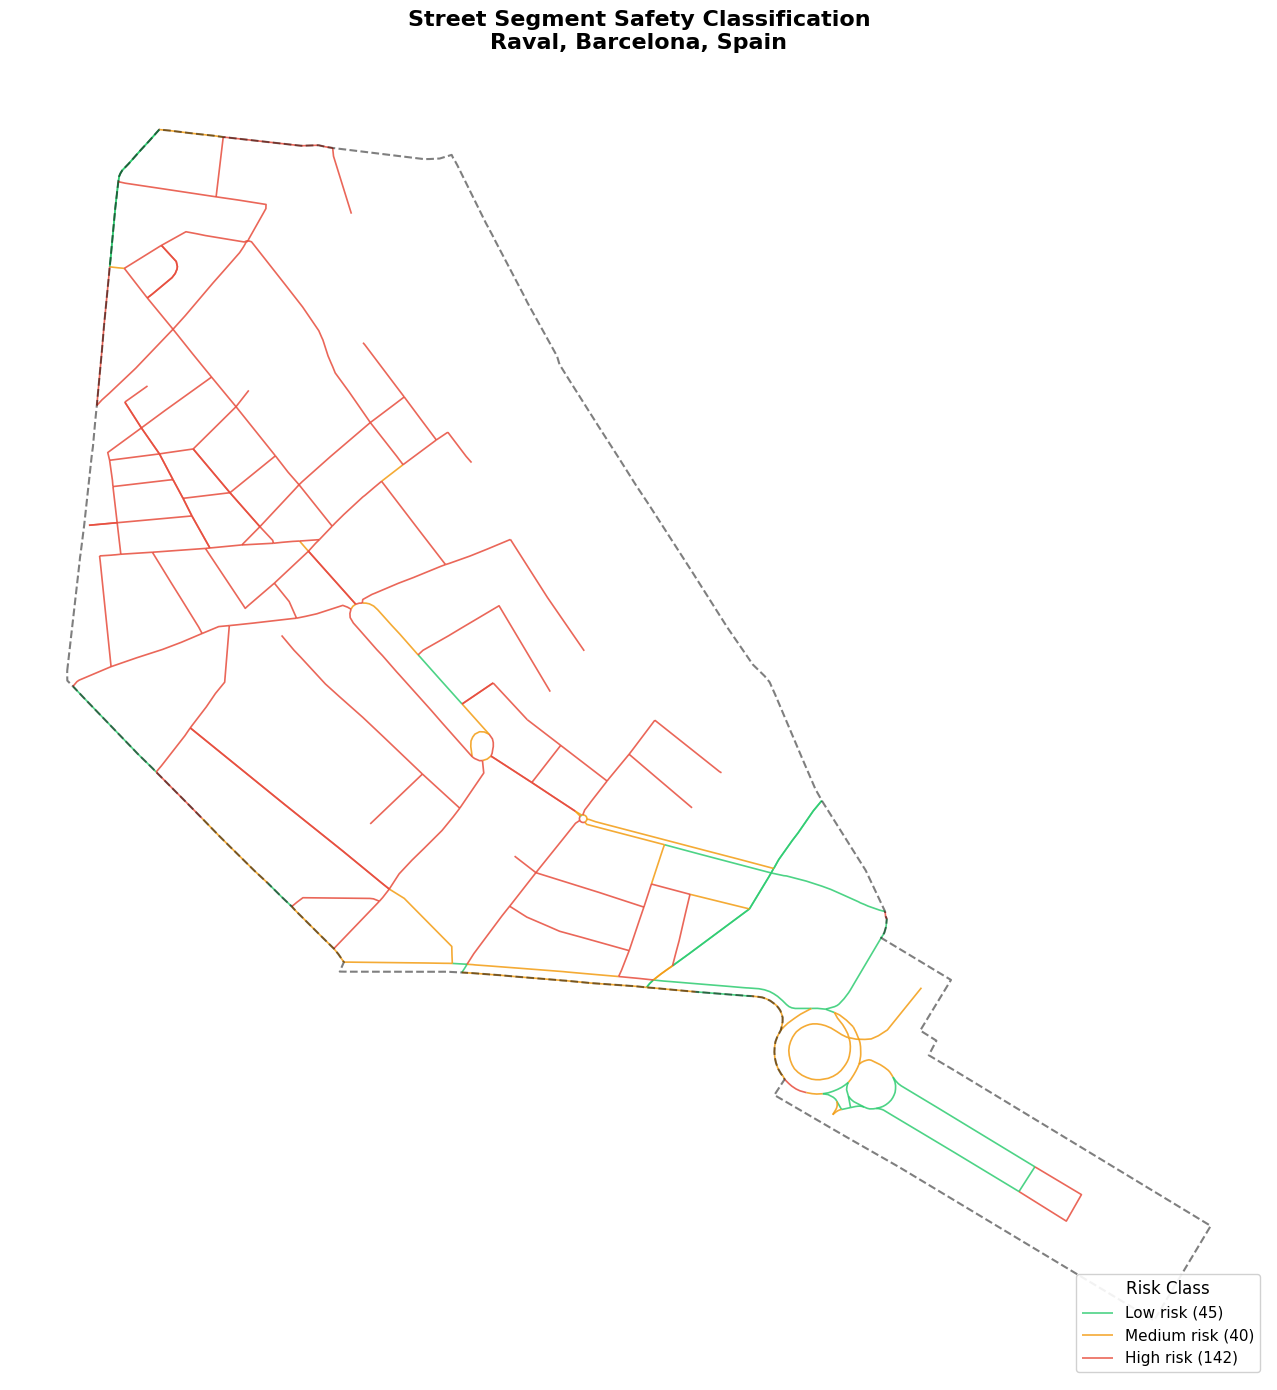

In [34]:
edges['color'] = edges['risk_class'].map(RISK_COLORS)

fig, ax = plt.subplots(figsize=(14, 14))

# Plot each risk class separately for legend control
for risk in RISK_ORDER:
    subset = edges[edges['risk_class'] == risk]
    subset.plot(
        ax=ax,
        color=RISK_COLORS[risk],
        linewidth=1.2,
        alpha=0.85,
        label=f'{risk.capitalize()} risk ({len(subset):,})'
    )

# Study area boundary
study_area.boundary.plot(ax=ax, color='black', linewidth=1.5, linestyle='--', alpha=0.5)

ax.set_title(f'Street Segment Safety Classification\n{PLACE}', fontsize=16, fontweight='bold', pad=15)
ax.legend(title='Risk Class', fontsize=11, title_fontsize=12, loc='lower right', framealpha=0.9)
ax.set_axis_off()
plt.tight_layout()

map_out = os.path.join(OUTPUT_DIR, f'{place_slug}_risk_map.png')
plt.savefig(map_out, dpi=150, bbox_inches='tight')
print(f'✓ Map saved to: {map_out}')
plt.show()

## Step 10: Summary

In [35]:
print('='*60)
print(f'CLASSIFICATION SUMMARY: {PLACE}')
print('='*60)
print(f'  Total segments classified : {len(edges):,}')
for cls in RISK_ORDER:
    n = (edges['risk_class'] == cls).sum()
    print(f'  {cls:6s} risk              : {n:6,} ({n/len(edges):.1%})')
print(f'  Mean prediction confidence: {edges["risk_probability"].mean():.3f}')
print(f'  CSV output : {csv_out}')
print(f'  Map output : {map_out}')
print()
print('Note: model was trained on London data. Classification of cities')
print('with significantly different spatial characteristics may be less reliable.')

CLASSIFICATION SUMMARY: Raval, Barcelona, Spain
  Total segments classified : 227
  low    risk              :     45 (19.8%)
  medium risk              :     40 (17.6%)
  high   risk              :    142 (62.6%)
  Mean prediction confidence: 0.977
  CSV output : C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\csv\raval_barcelona_spain_classified.csv
  Map output : C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\csv\raval_barcelona_spain_risk_map.png

Note: model was trained on London data. Classification of cities
with significantly different spatial characteristics may be less reliable.
